<a href="https://colab.research.google.com/github/Buddhiimz/DeepLearning_Project/blob/feature%2Fbuddhima/DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Update these paths to where you unzipped your dataset
train_dir = "/content/drive/MyDrive/DL Project/Flowers train"
test_dir  = "/content/drive/MyDrive/DL Project/Flowers test"

# Parameters
IMG_SIZE = (224, 224)         # higher resolution (helps accuracy)
BATCH_SIZE = 16               # adjust to GPU memory; lower if OOM
EPOCHS = 30                   # train longer, but early stopping will help


In [ ]:
# Stronger augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(train_gen.class_indices.keys())
print("Classes:", class_labels)
print("Train samples:", train_gen.samples, "Test samples:", test_gen.samples)


Found 2834 images belonging to 52 classes.
Found 745 images belonging to 52 classes.
Classes: ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n0051']
Train samples: 2834 Test samples: 745


In [ ]:
# compute class weights to reduce bias if classes are imbalanced
y_train = train_gen.classes  # labels from generator
classes_unique = np.unique(y_train)
class_weights_values = compute_class_weight(class_weight='balanced',
                                            classes=classes_unique,
                                            y=y_train)
class_weight = {i: w for i, w in enumerate(class_weights_values)}
print("Class weights:", class_weight)

Class weights: {0: np.float64(1.1354166666666667), 1: np.float64(1.1354166666666667), 2: np.float64(2.477272727272727), 3: np.float64(1.1122448979591837), 4: np.float64(3.0277777777777777), 5: np.float64(1.8793103448275863), 6: np.float64(2.369565217391304), 7: np.float64(3.40625), 8: np.float64(2.18), 9: np.float64(1.2674418604651163), 10: np.float64(2.8684210526315788), 11: np.float64(0.5860215053763441), 12: np.float64(1.0092592592592593), 13: np.float64(0.7785714285714286), 14: np.float64(1.09), 15: np.float64(1.2674418604651163), 16: np.float64(0.8257575757575758), 17: np.float64(0.3784722222222222), 18: np.float64(0.5240384615384616), 19: np.float64(1.0686274509803921), 20: np.float64(0.592391304347826), 21: np.float64(1.9464285714285714), 22: np.float64(2.0961538461538463), 23: np.float64(2.477272727272727), 24: np.float64(0.3303030303030303), 25: np.float64(2.8684210526315788), 26: np.float64(1.7580645161290323), 27: np.float64(0.6055555555555555), 28: np.float64(0.939655172413

In [ ]:
def build_improved_cnn(input_shape=(224,224,3), n_classes=None):
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))

    model.add(Dense(n_classes, activation='softmax'))
    return model

n_classes = train_gen.num_classes
model = build_improved_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), n_classes=n_classes)

# Compile with lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 52)             │        13,36

 Total params: 14,564,852 (55.56 MB)

 Trainable params: 14,561,844 (55.55 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [ ]:
checkpoint_path = "best_orchid_cnn.h5"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]


In [8]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0278 - loss: 5.1128
Epoch 1: val_loss improved from inf to 4.93533, saving model to best_orchid_cnn.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 941s 5s/step - accuracy: 0.0279 - loss: 5.1101 - val_accuracy: 0.0121 - val_loss: 4.9353 - learning_rate: 1.0000e-04
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0878 - loss: 4.0423
Epoch 2: val_loss improved from 4.93533 to 4.21559, saving model to best_orchid_cnn.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 1008s 5s/step - accuracy: 0.0879 - loss: 4.0416 - val_accuracy: 0.0376 - val_loss: 4.2156 - learning_rate: 1.0000e-04
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1150 - loss: 3.7291
Epoch 3: val_loss improved from 4.21559 to 3.42371, saving model to best_orchid_cnn.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 1010s 6s/step - accuracy: 0.1151 - loss: 3.7286 - val_accuracy: 0.1383 - val_loss: 3.4237 - learning_rate: 1.0000e-04
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1581 - loss: 3.4636
Epoch 4: val_loss improved from 3.42371 to 2.91737, saving model to best_orchid_cnn.h5


...

178/178 ━━━━━━━━━━━━━━━━━━━━ 995s 5s/step - accuracy: 0.4747 - loss: 1.7767 - val_accuracy: 0.5020 - val_loss: 1.9780 - learning_rate: 5.0000e-05
Epoch 22/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4956 - loss: 1.6915
Epoch 22: val_loss improved from 1.97801 to 1.95593, saving model to best_orchid_cnn.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 937s 5s/step - accuracy: 0.4957 - loss: 1.6911 - val_accuracy: 0.5181 - val_loss: 1.9559 - learning_rate: 5.0000e-05
Epoch 23/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4742 - loss: 1.6421
Epoch 23: val_loss did not improve from 1.95593
178/178 ━━━━━━━━━━━━━━━━━━━━ 943s 5s/step - accuracy: 0.4744 - loss: 1.6421 - val_accuracy: 0.5101 - val_loss: 1.9803 - learning_rate: 5.0000e-05
Epoch 24/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4961 - loss: 1.6438
Epoch 24: val_loss improved from 1.95593 to 1.88884, saving model to best_orchid_cnn.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 920s 5s/step - accuracy: 0.4962 - loss: 1.6436 - val_accuracy: 0.5342 - val_loss: 1.8888 - learning_rate: 5.0000e-05
Epoch 25/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5373 - loss: 1.5442
Epoch 25: val_loss did not improve from 1.88884
178/178 ━━━━━━━━━━━━━━━━━━━━ 917s 5s/step - accuracy: 0.5373 - loss: 1.5440 - val_accuracy: 0.4255 - val_loss: 2.5181 - learning_rate: 5.0000e-05
Epoch 26/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5046 - loss: 1.7094
Epoch 26: val_loss improved from 1.88884 to 1.78360, saving model to best_orchid_cnn.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 936s 5s/step - accuracy: 0.5047 - loss: 1.7088 - val_accuracy: 0.5517 - val_loss: 1.7836 - learning_rate: 5.0000e-05
Epoch 27/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5468 - loss: 1.4624
Epoch 27: val_loss did not improve from 1.78360
178/178 ━━━━━━━━━━━━━━━━━━━━ 992s 5s/step - accuracy: 0.5467 - loss: 1.4625 - val_accuracy: 0.5141 - val_loss: 2.0372 - learning_rate: 5.0000e-05
Epoch 28/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5285 - loss: 1.4984
Epoch 28: val_loss improved from 1.78360 to 1.72796, saving model to best_orchid_cnn.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 939s 5s/step - accuracy: 0.5285 - loss: 1.4982 - val_accuracy: 0.5866 - val_loss: 1.7280 - learning_rate: 5.0000e-05
Epoch 29/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5508 - loss: 1.4381
Epoch 29: val_loss did not improve from 1.72796
178/178 ━━━━━━━━━━━━━━━━━━━━ 973s 5s/step - accuracy: 0.5508 - loss: 1.4383 - val_accuracy: 0.5396 - val_loss: 1.8494 - learning_rate: 5.0000e-05
Epoch 30/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5448 - loss: 1.4718
Epoch 30: val_loss did not improve from 1.72796
178/178 ━━━━━━━━━━━━━━━━━━━━ 932s 5s/step - accuracy: 0.5449 - loss: 1.4716 - val_accuracy: 0.5503 - val_loss: 1.7793 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 28.


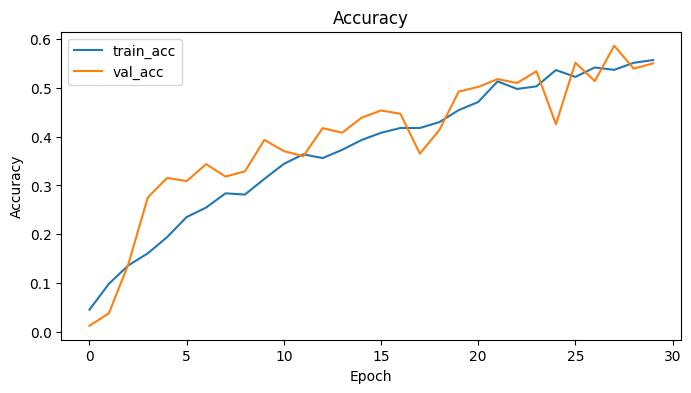

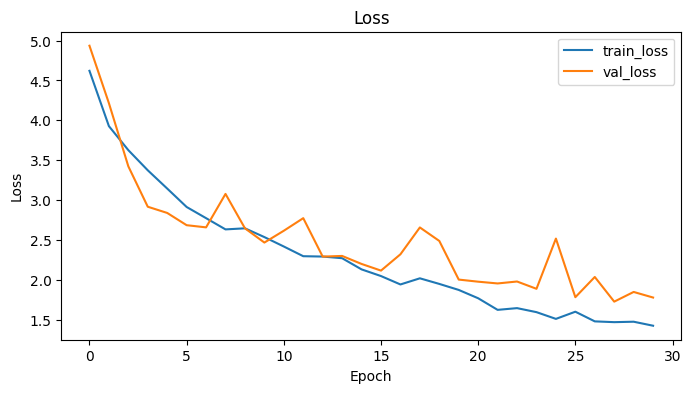

In [9]:
# Accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5361 - loss: 1.9023
Test accuracy: 0.5866, Test loss: 1.7280
47/47 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step


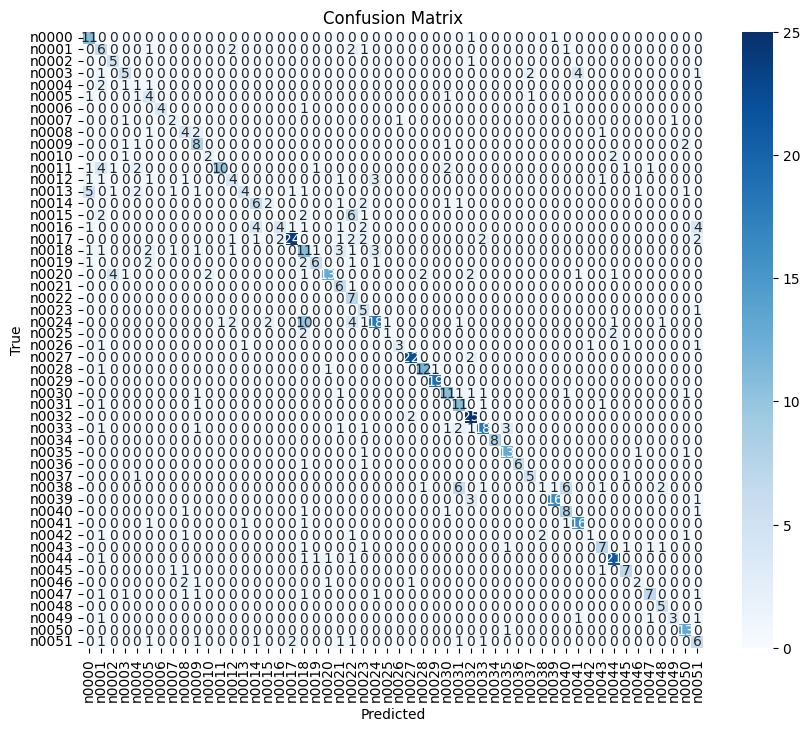

              precision    recall  f1-score   support

       n0000       0.50      0.85      0.63        13
       n0001       0.23      0.46      0.31        13
       n0002       0.45      0.83      0.59         6
       n0003       0.45      0.38      0.42        13
       n0004       0.12      0.20      0.15         5
       n0005       0.29      0.50      0.36         8
       n0006       1.00      0.67      0.80         6
       n0007       0.40      0.40      0.40         5
       n0008       0.36      0.50      0.42         8
       n0009       0.44      0.62      0.52        13
       n0010       0.50      0.40      0.44         5
       n0011       0.91      0.43      0.59        23
       n0012       0.40      0.31      0.35        13
       n0013       0.67      0.22      0.33        18
       n0014       0.50      0.46      0.48        13
       n0015       0.00      0.00      0.00        11
       n0016       0.67      0.22      0.33        18
       n0017       0.86    

In [10]:
# Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Predictions for report
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=class_labels))


In [15]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

print(f"Final Training Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1] * 100:.2f}%")


Final Training Accuracy: 0.5571630001068115
Final Validation Accuracy: 0.5503355860710144
Final Training Accuracy: 55.72%
Final Validation Accuracy: 55.03%


In [16]:
from tensorflow.keras.preprocessing import image

def predict_single(img_path, model, IMG_SIZE, class_labels, top_k=3):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    arr = image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr)[0]
    top_idx = probs.argsort()[-top_k:][::-1]
    print("Top predictions:")
    for i in top_idx:
        print(f"{class_labels[i]} : {probs[i]*100:.2f}%")
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Top: {class_labels[top_idx[0]]} ({probs[top_idx[0]]*100:.2f}%)")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Top predictions:
n0006 : 94.24%
n0036 : 1.68%
n0000 : 1.47%


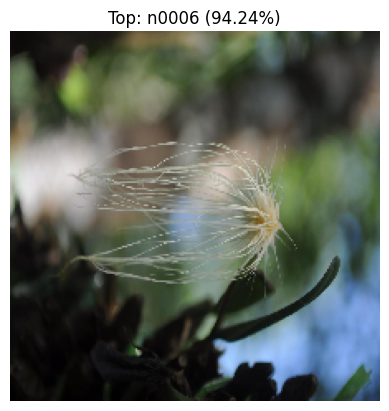

In [27]:
# Example usage — replace with your actual path
img_path = "/content/drive/MyDrive/DL Project/Flowers test/n0006/orchid-0001-α╕¬α╕┤α╕çα╣éα╕òα╕ƒα╕╣α╣êα╕éα╕▓α╕º_7.JPEG"

# Run prediction on the image
predict_single(img_path, model, IMG_SIZE, class_labels, top_k=3)
